In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


In [2]:
PATH_TO = Path("/Volumes/Extreme SSD/MIMIC")
# ── MIMIC-IV-ED tables ──
edstays = pd.read_csv(PATH_TO / "mimic-iv-ed-2.2/ed/edstays.csv" )     
triage  = pd.read_csv(PATH_TO / "mimic-iv-ed-2.2/ed/triage.csv")
diagnosis = pd.read_csv(PATH_TO / "mimic-iv-ed-2.2/ed/diagnosis.csv")
medrecon = pd.read_csv(PATH_TO / "mimic-iv-ed-2.2/ed/medrecon.csv")

# ── MIMIC-IV hosp tables ──
patients   = pd.read_csv(PATH_TO / "mimic-iv-3.1/hosp/patients.csv")
admissions = pd.read_csv(PATH_TO / "mimic-iv-3.1/hosp/admissions.csv")

# ── MIMIC-IV-Note ──
discharge_notes = pd.read_csv(PATH_TO / "mimic-iv-note-deidentified-free-text-clinical-notes-2.2/note/discharge.csv")

In [3]:
tables = {
    "edstays": edstays,
    "triage": triage,
    "diagnosis": diagnosis,
    "medrecon": medrecon,
    "patients": patients,
    "admissions": admissions,
    "discharge_notes": discharge_notes,
}

for name, df in tables.items():
    print(f"\n{'='*60}")
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"Columns: {list(df.columns)}")
    print(df.dtypes)


edstays: 425,087 rows × 9 cols
Columns: ['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'gender', 'race', 'arrival_transport', 'disposition']
subject_id             int64
hadm_id              float64
stay_id                int64
intime                object
outtime               object
gender                object
race                  object
arrival_transport     object
disposition           object
dtype: object

triage: 425,087 rows × 11 cols
Columns: ['subject_id', 'stay_id', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'acuity', 'chiefcomplaint']
subject_id          int64
stay_id             int64
temperature       float64
heartrate         float64
resprate          float64
o2sat             float64
sbp               float64
dbp               float64
pain               object
acuity            float64
chiefcomplaint     object
dtype: object

diagnosis: 899,050 rows × 6 cols
Columns: ['subject_id', 'stay_id', 'seq_num', 'icd_code', 'icd_version',

In [4]:
# Core merge: edstays + triage on stay_id
ed = edstays.merge(triage, on=["subject_id", "stay_id"], how="left")

# Add age from patients table
ed = ed.merge(
    patients[["subject_id", "anchor_age", "dod"]],
    on="subject_id",
    how="left",
)

# Flag: does this stay have a discharge note?
hadm_ids_with_notes = set(discharge_notes["hadm_id"].dropna().unique())
ed["has_note"] = ed["hadm_id"].isin(hadm_ids_with_notes)

print(f"Merged ED dataframe: {ed.shape[0]:,} rows × {ed.shape[1]} cols")
ed.head()

Merged ED dataframe: 425,087 rows × 21 cols


,subject_id,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint,anchor_age,dod,has_note
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,2180-05-06 23:30:00,F,WHITE,AMBULANCE,ADMITTED,98.4,70.0,16.0,97.0,106.0,63.0,0,3.0,"Abd pain, Abdominal distention",52.0,2180-09-09,True
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,2180-06-26 21:31:00,F,WHITE,AMBULANCE,ADMITTED,98.9,88.0,18.0,97.0,116.0,88.0,10,3.0,Abdominal distention,52.0,2180-09-09,True
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,2180-08-06 01:44:00,F,WHITE,AMBULANCE,ADMITTED,99.4,105.0,18.0,96.0,106.0,57.0,10,3.0,"n/v/d, Abd pain",52.0,2180-09-09,True
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,2180-07-23 05:54:00,F,WHITE,AMBULANCE,HOME,97.8,87.0,14.0,97.0,71.0,43.0,7,2.0,Hypotension,52.0,2180-09-09,True
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,2180-07-23 14:00:00,F,WHITE,AMBULANCE,ADMITTED,98.7,77.0,16.0,98.0,96.0,50.0,13,2.0,"Abdominal distention, Abd pain, LETHAGIC",52.0,2180-09-09,True


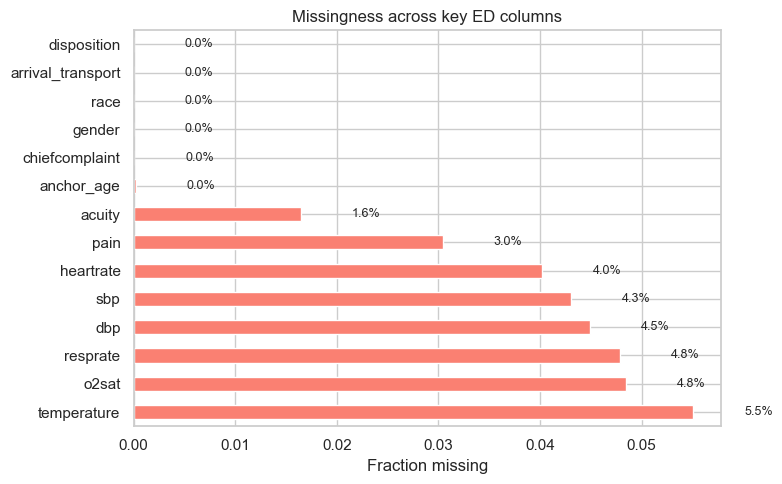


Acuity missing: 6,987 / 425,087 (1.6%)


In [5]:
cols_of_interest = [
    "gender", "race", "anchor_age", "arrival_transport", "disposition",
    "temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp",
    "pain", "acuity", "chiefcomplaint",
]

missing = ed[cols_of_interest].isnull().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
missing.plot.barh(ax=ax, color="salmon")
ax.set_xlabel("Fraction missing")
ax.set_title("Missingness across key ED columns")
for i, v in enumerate(missing.values):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nAcuity missing: {ed['acuity'].isna().sum():,} / {len(ed):,} "
      f"({ed['acuity'].isna().mean():.1%})")

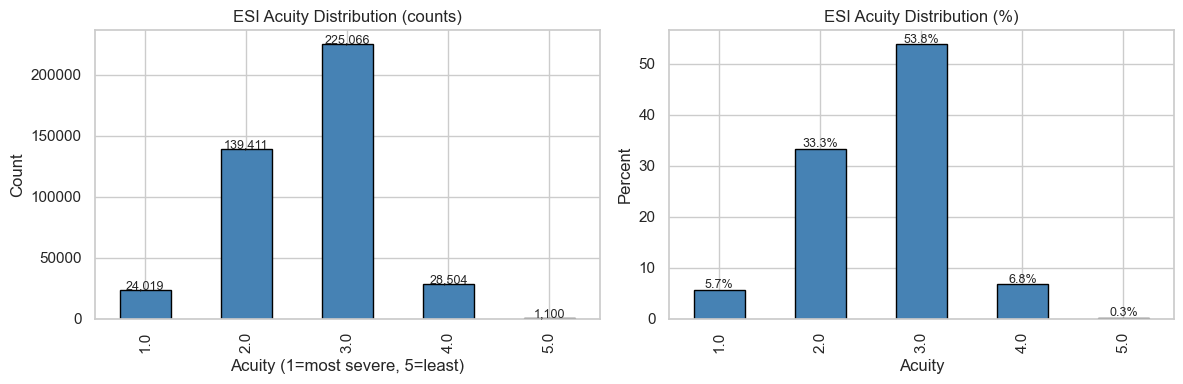

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
acuity_counts = ed["acuity"].value_counts().sort_index()
acuity_counts.plot.bar(ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("ESI Acuity Distribution (counts)")
axes[0].set_xlabel("Acuity (1=most severe, 5=least)")
axes[0].set_ylabel("Count")
for i, v in enumerate(acuity_counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

# Proportions
acuity_pct = ed["acuity"].value_counts(normalize=True).sort_index() * 100
acuity_pct.plot.bar(ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("ESI Acuity Distribution (%)")
axes[1].set_xlabel("Acuity")
axes[1].set_ylabel("Percent")
for i, v in enumerate(acuity_pct.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

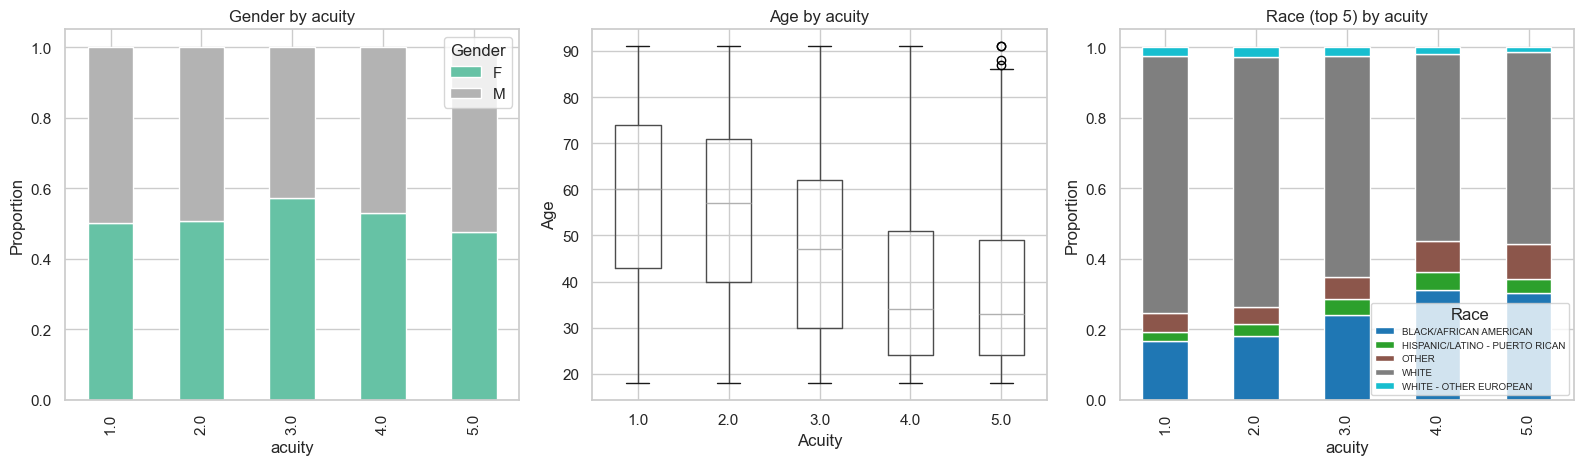

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender × acuity
pd.crosstab(ed["acuity"], ed["gender"], normalize="index").plot.bar(
    stacked=True, ax=axes[0], colormap="Set2"
)
axes[0].set_title("Gender by acuity")
axes[0].set_ylabel("Proportion")
axes[0].legend(title="Gender")

# Age by acuity
ed.boxplot(column="anchor_age", by="acuity", ax=axes[1])
axes[1].set_title("Age by acuity")
axes[1].set_xlabel("Acuity")
axes[1].set_ylabel("Age")
plt.suptitle("")  # remove auto-title from .boxplot()

# Race (top 5) × acuity
top_races = ed["race"].value_counts().head(5).index
ed_top_race = ed[ed["race"].isin(top_races)]
pd.crosstab(ed_top_race["acuity"], ed_top_race["race"], normalize="index").plot.bar(
    stacked=True, ax=axes[2], colormap="tab10"
)
axes[2].set_title("Race (top 5) by acuity")
axes[2].set_ylabel("Proportion")
axes[2].legend(title="Race", fontsize=7)

plt.tight_layout()
plt.show()

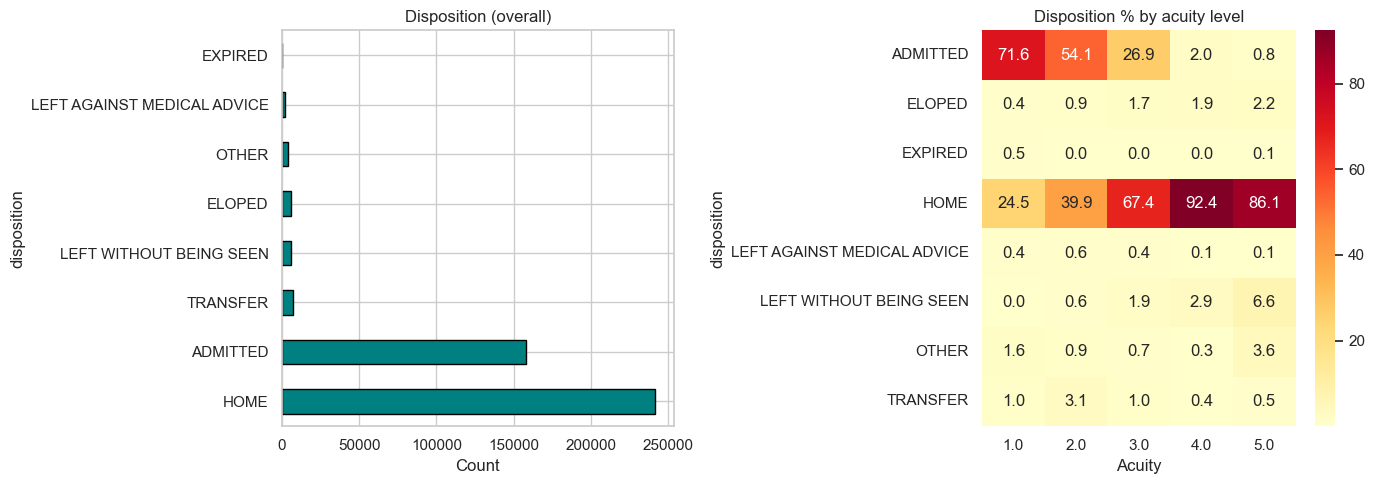

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall disposition
disp_counts = ed["disposition"].value_counts()
disp_counts.plot.barh(ax=axes[0], color="teal", edgecolor="black")
axes[0].set_title("Disposition (overall)")
axes[0].set_xlabel("Count")

# Disposition × acuity heatmap
ct = pd.crosstab(ed["disposition"], ed["acuity"], normalize="columns") * 100
sns.heatmap(ct, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Disposition % by acuity level")
axes[1].set_xlabel("Acuity")

plt.tight_layout()
plt.show()

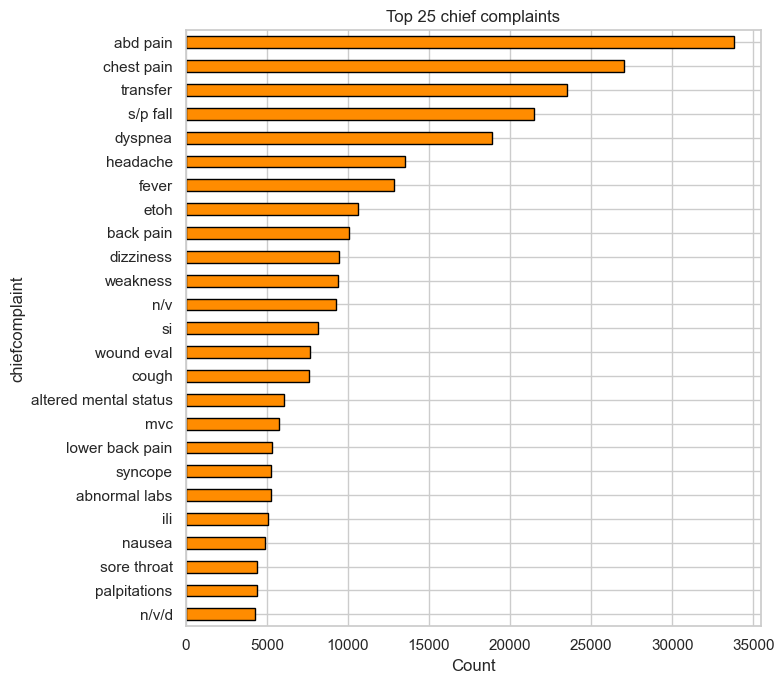


Top 5 complaints per acuity level:

  Acuity 1:
    transfer: 3,032
    dyspnea: 2,019
    altered mental status: 1,465
    s/p fall: 1,216
    hypotension: 1,061

  Acuity 2:
    chest pain: 16,512
    transfer: 14,079
    dyspnea: 11,356
    s/p fall: 7,829
    si: 7,821

  Acuity 3:
    abd pain: 25,698
    s/p fall: 11,140
    chest pain: 9,497
    headache: 8,471
    etoh: 7,246

  Acuity 4:
    back pain: 1,160
    lower back pain: 1,124
    s/p fall: 1,073
    rash: 950
    wound eval: 888

  Acuity 5:
    suture removal: 129
    med refill: 107
    wound eval: 54
    rash: 26
    dental pain: 22


In [10]:
# Flatten comma-separated chief complaints
all_complaints = (
    ed["chiefcomplaint"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .str.lower()
)

complaint_freq = all_complaints.value_counts().head(25)

fig, ax = plt.subplots(figsize=(8, 7))
complaint_freq.plot.barh(ax=ax, color="darkorange", edgecolor="black")
ax.set_xlabel("Count")
ax.set_title("Top 25 chief complaints")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Chief complaints per acuity level (top 5 per level)
print("\nTop 5 complaints per acuity level:")
for level in sorted(ed["acuity"].dropna().unique()):
    subset = ed[ed["acuity"] == level]["chiefcomplaint"].dropna()
    top = subset.str.split(",").explode().str.strip().str.lower().value_counts().head(5)
    print(f"\n  Acuity {int(level)}:")
    for complaint, count in top.items():
        print(f"    {complaint}: {count:,}")

Total ED stays:            425,087
Admitted to hospital:      203,016 (47.8%)
Have discharge note:       155,565 (36.6%)


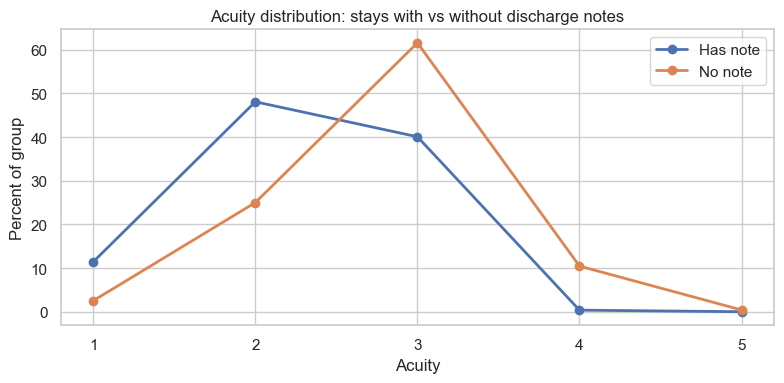

In [11]:
admitted = ed[ed["hadm_id"].notna()]
print(f"Total ED stays:            {len(ed):,}")
print(f"Admitted to hospital:      {len(admitted):,} ({len(admitted)/len(ed):.1%})")
print(f"Have discharge note:       {ed['has_note'].sum():,} ({ed['has_note'].mean():.1%})")

# Acuity distribution for stays WITH vs WITHOUT notes
fig, ax = plt.subplots(figsize=(8, 4))
for label, subset in [("Has note", ed[ed["has_note"]]), ("No note", ed[~ed["has_note"]])]:
    acuity_dist = subset["acuity"].value_counts(normalize=True).sort_index() * 100
    ax.plot(acuity_dist.index, acuity_dist.values, marker="o", label=label, linewidth=2)
ax.set_xlabel("Acuity")
ax.set_ylabel("Percent of group")
ax.set_title("Acuity distribution: stays with vs without discharge notes")
ax.legend()
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

In [12]:
# Grab one note for a high-acuity admitted patient
sample_hadm = ed.loc[
    (ed["has_note"]) & (ed["acuity"] == 2), "hadm_id"
].iloc[0]

sample_note = discharge_notes.loc[
    discharge_notes["hadm_id"] == sample_hadm, "text"
].iloc[0]

print(f"hadm_id: {sample_hadm}")
print(f"Note length: {len(sample_note):,} chars")
print("=" * 60)
print(sample_note[:3000])
print("\n... [truncated]")

hadm_id: 29079034.0
Note length: 10,608 chars
 
Name:  ___                     Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   F
 
Service: MEDICINE
 
Allergies: 
Percocet / Vicodin
 
Attending: ___
 
Chief Complaint:
altered mental status
 
Major Surgical or Invasive Procedure:
none
 
History of Present Illness:
Mrs. ___ is a ___ female with HIV on HAART, COPD, HCV 
cirrhosis complicated by ascites and hepatic encephalopathy who 
initially presented to the ED yesterday with hypotension after a 
paracentesis.  
The patient has had accelerated decompensation of her cirrhosis 
recently with worsening ascites, and she is maintained on twice 
weekly paracentesis. She was at her regular session yesterday 
when she had hypotension to SBP ___ and felt lightheadedness. 
Per the patient, that's when her memory started to get fuzzy. 
She does not have much recollection of what happened since then. 
Her outpatient hepatologist saw 

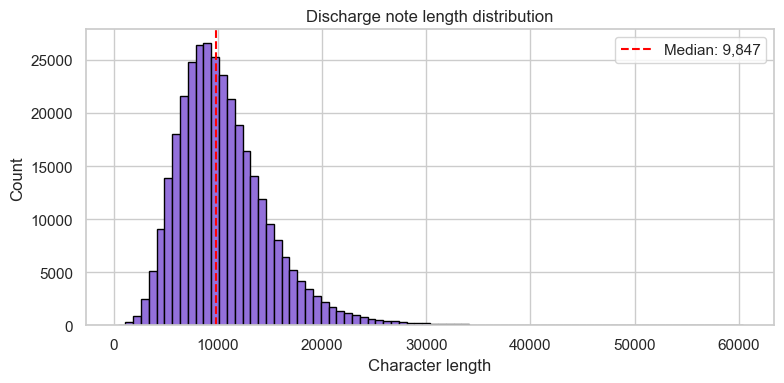

count    331793.000000
mean      10550.960270
std        4452.124302
min         353.000000
25%        7462.000000
50%        9847.000000
75%       12831.000000
max       60381.000000
Name: text, dtype: float64


In [13]:
note_lengths = discharge_notes["text"].str.len()

fig, ax = plt.subplots(figsize=(8, 4))
note_lengths.hist(bins=80, ax=ax, color="mediumpurple", edgecolor="black")
ax.axvline(note_lengths.median(), color="red", linestyle="--", label=f"Median: {note_lengths.median():,.0f}")
ax.set_xlabel("Character length")
ax.set_ylabel("Count")
ax.set_title("Discharge note length distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(note_lengths.describe())

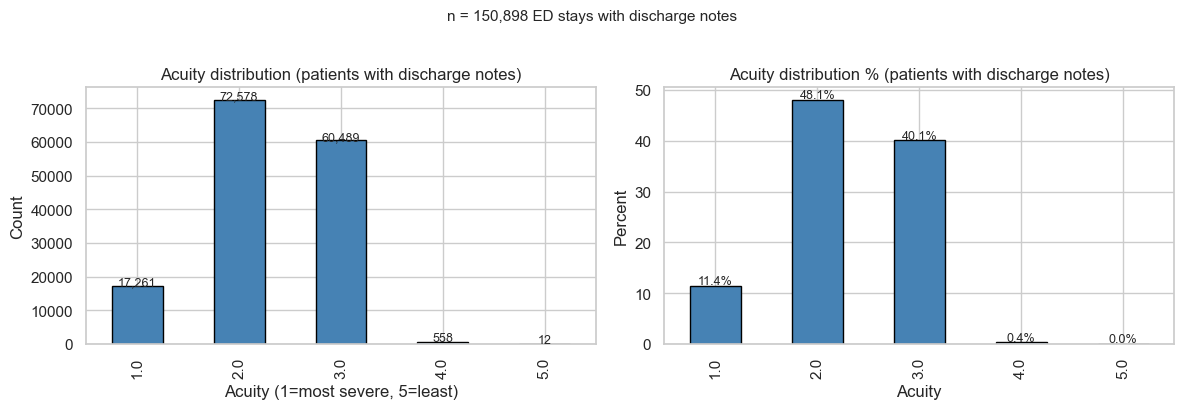

In [17]:
admitted_with_notes = ed[ed["has_note"] & ed["acuity"].notna()]

acuity_counts = admitted_with_notes["acuity"].value_counts().sort_index()
acuity_pct = (acuity_counts / acuity_counts.sum()) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

acuity_counts.plot.bar(ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Acuity distribution (patients with discharge notes)")
axes[0].set_xlabel("Acuity (1=most severe, 5=least)")
axes[0].set_ylabel("Count")
for i, v in enumerate(acuity_counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=9)

acuity_pct.plot.bar(ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("Acuity distribution % (patients with discharge notes)")
axes[1].set_xlabel("Acuity")
axes[1].set_ylabel("Percent")
for i, v in enumerate(acuity_pct.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.suptitle(f"n = {len(admitted_with_notes):,} ED stays with discharge notes", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
print("="*60)
print("SUMMARY FOR PAPER")
print("="*60)
acuity_valid = ed["acuity"].notna()
print(f"Total ED stays:              {len(ed):,}")
print(f"Unique patients:             {ed['subject_id'].nunique():,}")
print(f"Stays with valid acuity:     {acuity_valid.sum():,} ({acuity_valid.mean():.1%})")
print(f"Stays with discharge notes:  {ed['has_note'].sum():,}")
print(f"Date range:                  {ed['intime'].min()} → {ed['intime'].max()}")
print(f"\nAcuity distribution:")
for level in sorted(ed["acuity"].dropna().unique()):
    n = (ed["acuity"] == level).sum()
    print(f"  ESI {int(level)}: {n:>7,}  ({n/acuity_valid.sum():.1%})")
print(f"\nAge: mean={ed['anchor_age'].mean():.1f}, median={ed['anchor_age'].median():.0f}")
print(f"Gender: {ed['gender'].value_counts().to_dict()}")

SUMMARY FOR PAPER
Total ED stays:              425,087
Unique patients:             205,504
Stays with valid acuity:     418,100 (98.4%)
Stays with discharge notes:  155,565
Date range:                  2110-01-11 01:45:00 → 2212-04-05 23:23:00

Acuity distribution:
  ESI 1:  24,019  (5.7%)
  ESI 2: 139,411  (33.3%)
  ESI 3: 225,066  (53.8%)
  ESI 4:  28,504  (6.8%)
  ESI 5:   1,100  (0.3%)

Age: mean=50.3, median=50
Gender: {'F': 229898, 'M': 195189}
